In [72]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from ipywidgets import *
import warnings
warnings.simplefilter(action='ignore', category=Warning)
%matplotlib inline

In [73]:

columnz = ['Trace_no', 'Mode', 'Total_host', 'Host_no', 'Segment_no', 
           'Arr_time', 'Del_Time', 'Stall_Dur', 'Rep_Level', ' Del_Rate', 'Act_Rate',
           'Byte_Size', 'Buff_Level', 'Algorithm', 'Seg_Dur', 'Width', 'Height',
           'Play_Pos', 'RTT_app', 'P1203', 'Clae', 'Duanmu', 'Yin', 'Yu',
           'persegment_RTT', 'Throughput', 'Packets']
df = pd.read_csv("../Data/Processed/dataset.csv", names = columnz, skiprows=[0])
# df = pd.read_csv("../Data/Processed/dataset_delay15ms_jitter0.13ms.csv")

# df = df.rename(columns={'column':'Column','type':'Mode','total_users':'Total_host','user_no':'Host_no','intSeg':'Segment_no','intArr':'Arr_time','intDel':'Del_Time', 'intSta':'Stall_Dur', 'intRep':'Rep_Level','intDelRate':'Del_Rate','intActRate':'Act_Rate', 'intByteSize':'Byte_Size', 'floatBuf':'Buff_Level',  'algorithm_used':'Algorithm',  'seg_Dur': 'Seg_Dur','width': 'Width','height': 'Height',  'play_Pos':'Play_Pos', 'RTT':'RTT_app',  'P1203':' P.1203', 'Clae':'Clae', 'Duanmu':' Duanmu', 'Yin':'Yin', 'Yu':'Yu', 'persegment_RTT':'RTT_net','Throughput':'Throughput','Packets':'Packets'})
print ("shape --> ", df.shape)
df.columns



shape -->  (3600, 27)


Index(['Trace_no', 'Mode', 'Total_host', 'Host_no', 'Segment_no', 'Arr_time',
       'Del_Time', 'Stall_Dur', 'Rep_Level', ' Del_Rate', 'Act_Rate',
       'Byte_Size', 'Buff_Level', 'Algorithm', 'Seg_Dur', 'Width', 'Height',
       'Play_Pos', 'RTT_app', 'P1203', 'Clae', 'Duanmu', 'Yin', 'Yu',
       'persegment_RTT', 'Throughput', 'Packets'],
      dtype='object')

In [74]:
df

,Trace_no,Mode,Total_host,Host_no,Segment_no,Arr_time,Del_Time,Stall_Dur,Rep_Level,Del_Rate,...,Play_Pos,RTT_app,P1203,Clae,Duanmu,Yin,Yu,persegment_RTT,Throughput,Packets
0,12,static,1,1,1,Arr_time,Del_Time,Stall_Dur,Rep_Level,Del_Rate,...,Play_Pos,RTT,P.1203,Clae,Duanmu,Yin,Yu,0.030,1.018182e+07,2
1,12,static,1,1,2,22,22,0,239,775,...,0,8.113,1.871,0.000,51.077,-5760.485,0.240,0.419,3.346154e+06,54
2,12,static,1,1,3,414,115,0,766,18722,...,2000,14.003,2.143,0.250,53.289,479.030,0.503,2.772,3.467104e+06,250
3,12,static,1,1,4,1339,572,0,3918,26349,...,4000,17.366,3.103,0.000,62.177,1245.328,1.641,3.711,3.465470e+06,290
4,12,static,1,1,5,2243,666,0,4375,26506,...,6000,13.710,3.374,0.000,66.639,5163.749,2.325,5.771,3.409788e+06,197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,120,static,1,1,56,65973,790,0,1801,8713,...,108000,11.982,4.311,3.348,76.367,199020.851,3.741,26.190,1.146780e+06,165
3596,120,static,1,1,57,67595,975,0,1801,8866,...,110000,11.471,4.277,3.271,76.124,200822.185,3.706,22.001,1.143825e+06,117
3597,120,static,1,1,58,68869,729,0,1801,8666,...,112000,11.017,4.241,3.199,75.890,202623.519,3.673,26.278,1.169381e+06,231
3598,120,static,1,1,59,70873,1449,0,3918,9161,...,114000,10.769,4.263,3.220,76.020,204424.853,3.677,26.475,1.158406e+06,170


In [75]:
# def interactive_contol(nb_Nodes, Algorithm, Target):
#     t= 'static' #Mobility    
#     c= nb_Nodes
#     u= 1 #Host_no
#     a=Algorithm
#     tr= Target
#     tu= 1 #Total_host
    
#     if a=='Rate Based':
#         case1= df[(df['Algorithm']=='conventional')]
#         case2= df[(df['Algorithm']=='exponential')]
#         a1='Conventional'
#         a2='Exponential'
#     elif a=='Buffer Based':
#         case1= df[(df['Algorithm']=='bba')]
#         case2= df[(df['Algorithm']=='logistic')]
#         a1='BBA'
#         a2='Logistic'
#     else:
#         case1= df[(df['Algorithm']=='arbiter')]
#         case2= df[(df['Algorithm']=='elastic')]
#         a1='Arbiter +'
#         a2='Elastic'
    
#     case1_final = case1[( case1['Trace_no']==c) & ( case1['Mode']==t) & ( case1['Host_no']==u) & ( case1['Total_host']==tu)]
#     case2_final = case2[( case2['Trace_no']==c) & ( case2['Mode']==t) & ( case2['Host_no']==u) & ( case2['Total_host']==tu)]
    
#     if   c==8  and t=='driving': title= '0.5 - 3 Mbps';
#     elif c==10 and t=='driving': title= '6 - 14 Mbps';
#     elif c==1  and t=='driving': title= '38.26 - 10.33 Mbps';
#     elif c==2  and t=='driving': title= '29.33 - 10.55 Mbps';
#     elif c==4  and t=='static':  title= '72.42 - 9 Mbps';
#     elif c==5  and t=='static':  title= '70 - 20 Mbps';  
#     elif c==7  and t=='static':  title= '4 - 7.6 Mbps';
#     elif c==9  and t=='static':  title= '0.5 - 6 Mbps';
#     elif c==11 and t=='static':  title= '8 - 57 Mbps';    
#     else: title='5g factory automation use case'
    
#     plt.style.use('classic')
#     fig = plt.figure(figsize=(10,5))
#     with plt.style.context('Solarize_Light2'):
#         fig.set_facecolor('white')
#         plt.rcParams['axes.facecolor'] = 'white'
#         plt.plot(case1_final['Segment_no'], case1_final[tr], label=a1)
#         plt.plot(case2_final['Segment_no'], case2_final[tr], label=a2, linestyle='--', color='orange')
#         plt.title(title, fontsize=11)
#         plt.xlabel('Segments (2 sec)', fontsize=12, color='black')
#         plt.ylabel(tr, fontsize=12, color='black')
#         plt.legend(loc='best',frameon=False)
#         plt.grid(axis='y', c='#D3D3D3')
#         plt.grid(axis='x', c='#D3D3D3')
#         plt.tick_params(axis='x',  colors='black')
#         # ymax = np.linspace(0, max(case1_final[tr]), 50)
#         plt.tick_params(axis='y', colors='black')
#         # plt.yticks(np.arange(0, int(float(max(max(case1_final[tr]), max(case2_final[tr]))))+1))
#     plt.show() 

In [76]:
def interactive_contol(nb_Nodes, Algorithm, Target):
    t= 'static' #Mobility    
    c= nb_Nodes
    u= 1 #Host_no
    a=Algorithm
    tr= Target
    tu= 1 #Total_host
    
    if a=='Rate Based':
        case1= df[(df['Algorithm']=='conventional')]
        case2= df[(df['Algorithm']=='exponential')]
        a1='Conventional'
        a2='Exponential'
    elif a=='Buffer Based':
        case1= df[(df['Algorithm']=='bba')]
        case2= df[(df['Algorithm']=='logistic')]
        a1='BBA'
        a2='Logistic'
    else:
        case1= df[(df['Algorithm']=='arbiter')]
        case2= df[(df['Algorithm']=='elastic')]
        a1='Arbiter +'
        a2='Elastic'
    
    case1_final = case1[( case1['Trace_no']==c) & ( case1['Mode']==t) & ( case1['Host_no']==u) & ( case1['Total_host']==tu)]
    case2_final = case2[( case2['Trace_no']==c) & ( case2['Mode']==t) & ( case2['Host_no']==u) & ( case2['Total_host']==tu)]
    
    if   c==8  and t=='driving': title= '0.5 - 3 Mbps';
    elif c==10 and t=='driving': title= '6 - 14 Mbps';
    elif c==1  and t=='driving': title= '38.26 - 10.33 Mbps';
    elif c==2  and t=='driving': title= '29.33 - 10.55 Mbps';
    elif c==4  and t=='static':  title= '72.42 - 9 Mbps';
    elif c==5  and t=='static':  title= '70 - 20 Mbps';  
    elif c==7  and t=='static':  title= '4 - 7.6 Mbps';
    elif c==9  and t=='static':  title= '0.5 - 6 Mbps';
    elif c==11 and t=='static':  title= '8 - 57 Mbps';    
    else: title='5g factory automation use case'
    
    plt.style.use('classic')
    fig = plt.figure(figsize=(10,5))
    with plt.style.context('Solarize_Light2'):
        fig.set_facecolor('white')
        plt.rcParams['axes.facecolor'] = 'white'
        plt.plot(case1_final['Segment_no'], case1_final[tr].apply(float), label=a1)
        plt.plot(case2_final['Segment_no'], case2_final[tr].apply(float), label=a2, linestyle='--', color='orange')
        plt.title(title, fontsize=11)
        plt.xlabel('Segments (2 sec)', fontsize=12, color='black')
        plt.ylabel(tr, fontsize=12, color='black')
        plt.legend(loc='center left',  bbox_to_anchor=(1, 0.5))
        plt.grid(axis='y', c='#D3D3D3')
        plt.grid(axis='x', c='#D3D3D3')
        plt.tick_params(axis='x',  colors='black')
        plt.tick_params(axis='y', colors='black')
        ymaxmax = max([max(case1_final[tr].apply(float)), max(case2_final[tr].apply(float))])
        yminmin = min([min(case1_final[tr].apply(float)), min(case2_final[tr].apply(float))])
        ymax = np.linspace(yminmin, ymaxmax, 10)
        if (tr!='persegment_RTT') : plt.yticks(ymax)
    plt.show()

In [77]:
# 24nodes  29.4375   31.90625   20.125    0.160400
interact(interactive_contol, nb_Nodes=[12, 24, 36, 48, 60, 72, 84, 96, 108, 120],\
         Algorithm=['Rate Based','Hybrid', 'Buffer Based' ], 
         Target=['Clae', 'Duanmu','Yin', 'Yu','P1203', 'persegment_RTT','Throughput', 'Packets','Arr_time','Del_Time', 
                 'Stall_Dur', 'Del_Rate', 'Act_Rate', 'Byte_Size',  'Buff_Level'])

interactive(children=(Dropdown(description='nb_Nodes', options=(12, 24, 36, 48, 60, 72, 84, 96, 108, 120), val…

<function __main__.interactive_contol(nb_Nodes, Algorithm, Target)>

<Figure size 640x480 with 0 Axes>

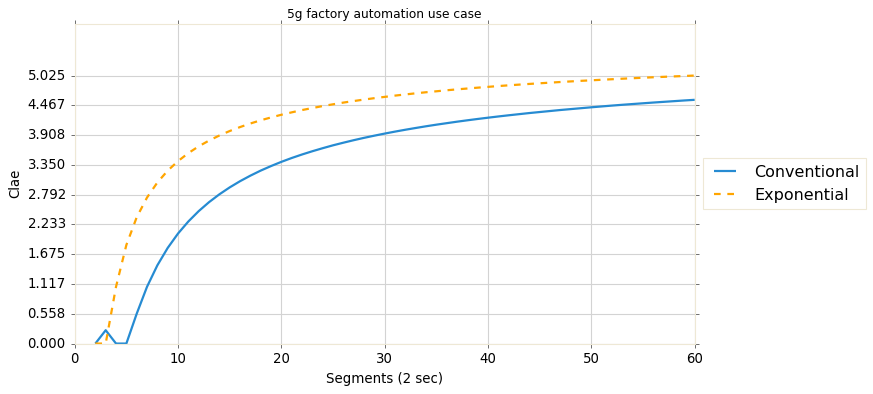

In [78]:
plt.clf()
t= 'static' #Mobility    
c= 12
u= 1 #Host_no
a='Rate Based'
tr= "Clae"
tu= 1 #Total_host
case1= df[(df['Algorithm']=='conventional')]
case2= df[(df['Algorithm']=='exponential')]
case1_final = case1[( case1['Trace_no']==c) & ( case1['Mode']==t) & ( case1['Host_no']==u) & ( case1['Total_host']==tu)]
case2_final = case2[( case2['Trace_no']==c) & ( case2['Mode']==t) & ( case2['Host_no']==u) & ( case2['Total_host']==tu)]
# case1_final

a1='Conventional'
a2='Exponential'

title='5g factory automation use case'

plt.style.use('classic')
fig = plt.figure(figsize=(10,5))
with plt.style.context('Solarize_Light2'):
    fig.set_facecolor('white')
    plt.rcParams['axes.facecolor'] = 'white'
    plt.plot(case1_final['Segment_no'], case1_final[tr].apply(float), label=a1)
    plt.plot(case2_final['Segment_no'], case2_final[tr].apply(float), label=a2, linestyle='--', color='orange')
    plt.title(title, fontsize=11)
    plt.xlabel('Segments (2 sec)', fontsize=12, color='black')
    plt.ylabel(tr, fontsize=12, color='black')
    # plt.legend(loc='best',frameon=False)
    plt.legend(loc='center left',  bbox_to_anchor=(1, 0.5))
    plt.grid(axis='y', c='#D3D3D3')
    plt.grid(axis='x', c='#D3D3D3')
    plt.tick_params(axis='x',  colors='black')
    # ymax = [str(x) for x in np.linspace(0, max(case1_final[tr].apply(float)), 20)]
    ymaxmax = max([max(case1_final[tr].apply(float)), max(case2_final[tr].apply(float))])
    ymax = np.linspace(0, ymaxmax, 10)
    plt.yticks(ymax)
    plt.tick_params(axis='y', colors='black')

plt.show()

In [79]:
df

,Trace_no,Mode,Total_host,Host_no,Segment_no,Arr_time,Del_Time,Stall_Dur,Rep_Level,Del_Rate,...,Play_Pos,RTT_app,P1203,Clae,Duanmu,Yin,Yu,persegment_RTT,Throughput,Packets
0,12,static,1,1,1,Arr_time,Del_Time,Stall_Dur,Rep_Level,Del_Rate,...,Play_Pos,RTT,P.1203,Clae,Duanmu,Yin,Yu,0.030,1.018182e+07,2
1,12,static,1,1,2,22,22,0,239,775,...,0,8.113,1.871,0.000,51.077,-5760.485,0.240,0.419,3.346154e+06,54
2,12,static,1,1,3,414,115,0,766,18722,...,2000,14.003,2.143,0.250,53.289,479.030,0.503,2.772,3.467104e+06,250
3,12,static,1,1,4,1339,572,0,3918,26349,...,4000,17.366,3.103,0.000,62.177,1245.328,1.641,3.711,3.465470e+06,290
4,12,static,1,1,5,2243,666,0,4375,26506,...,6000,13.710,3.374,0.000,66.639,5163.749,2.325,5.771,3.409788e+06,197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,120,static,1,1,56,65973,790,0,1801,8713,...,108000,11.982,4.311,3.348,76.367,199020.851,3.741,26.190,1.146780e+06,165
3596,120,static,1,1,57,67595,975,0,1801,8866,...,110000,11.471,4.277,3.271,76.124,200822.185,3.706,22.001,1.143825e+06,117
3597,120,static,1,1,58,68869,729,0,1801,8666,...,112000,11.017,4.241,3.199,75.890,202623.519,3.673,26.278,1.169381e+06,231
3598,120,static,1,1,59,70873,1449,0,3918,9161,...,114000,10.769,4.263,3.220,76.020,204424.853,3.677,26.475,1.158406e+06,170
